---
title: "Job Market Salary Analysis"
jupyter:
  output: true
format:
  html:
    code-tools: false
    code-fold: false
    echo: false
    warning: false
    message: false
---


In [5]:
import pandas as pd

df = pd.read_csv("data/lightcast_job_postings.csv", low_memory=False)


## 1. Salary Distribution by Industry
*This visualization examines median salary differences across major U.S. industries.*

In [9]:
industry_salary = (
    df.groupby("NAICS2_NAME")["SALARY"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

top10 = (
    df.groupby("NAICS2_NAME")["SALARY"]
    .median()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"NAICS2_NAME": "Industry", "SALARY": "Median Salary"})
)


styled_top10 = (
    top10.style
    .set_caption("Top 10 Industries by Median Annual Salary")     # ✔ REQUIRED for Quarto
    .format({"Median Salary": "${:,.0f}"})
    .hide(axis="index")
    .set_table_styles([
        # Caption styling
        {"selector": "caption",
         "props": [
             ("font-size", "20px"),
             ("font-weight", "bold"),
             ("text-align", "center"),
             ("padding", "10px")
         ]},

        # Header cells
        {"selector": "th",
         "props": [
             ("background-color", "#003049"),
             ("color", "white"),
             ("font-size", "14px"),
             ("font-weight", "bold"),
             ("text-align", "center"),
             ("padding", "8px")
         ]},

        # Data cells
        {"selector": "td",
         "props": [
             ("font-size", "13px"),
             ("padding", "6px")
         ]},
    ])
    .background_gradient(cmap="Blues", subset=["Median Salary"])
)

styled_top10


Industry,Median Salary
Accommodation and Food Services,"$149,850"
Information,"$132,600"
"Professional, Scientific, and Technical Services","$130,000"
Manufacturing,"$121,300"
Retail Trade,"$119,925"
Finance and Insurance,"$118,100"
Construction,"$118,098"
Utilities,"$114,950"
Unclassified Industry,"$105,000"
Management of Companies and Enterprises,"$101,400"



The table above highlights the ten industries offering the highest median annual salaries in the dataset. Accommodation and Food Services leads all sectors with a median salary of $149,850, followed closely by Information and the Professional, Scientific, and Technical Services sector, both of which consistently demonstrate strong compensation levels. These industries typically require advanced skills, technical expertise, and specialized knowledge, contributing to their elevated pay scales.

Manufacturing, Retail Trade, Finance and Insurance, and Construction also rank among the top-paying industries, reflecting robust demand for skilled labor across diverse economic sectors. Even traditionally steady fields such as Utilities and Management of Companies and Enterprises remain competitive, offering salaries above the national median. Overall, the data underscores the importance of industry selection in shaping earning potential and highlights areas where workers with specialized competencies can expect strong financial returns.

## 2. Top 10 Highest-Paying Industries
*This table ranks industries by their median salary using Lightcast job postings data.*

/tmp/ipykernel_28356/3185174833.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


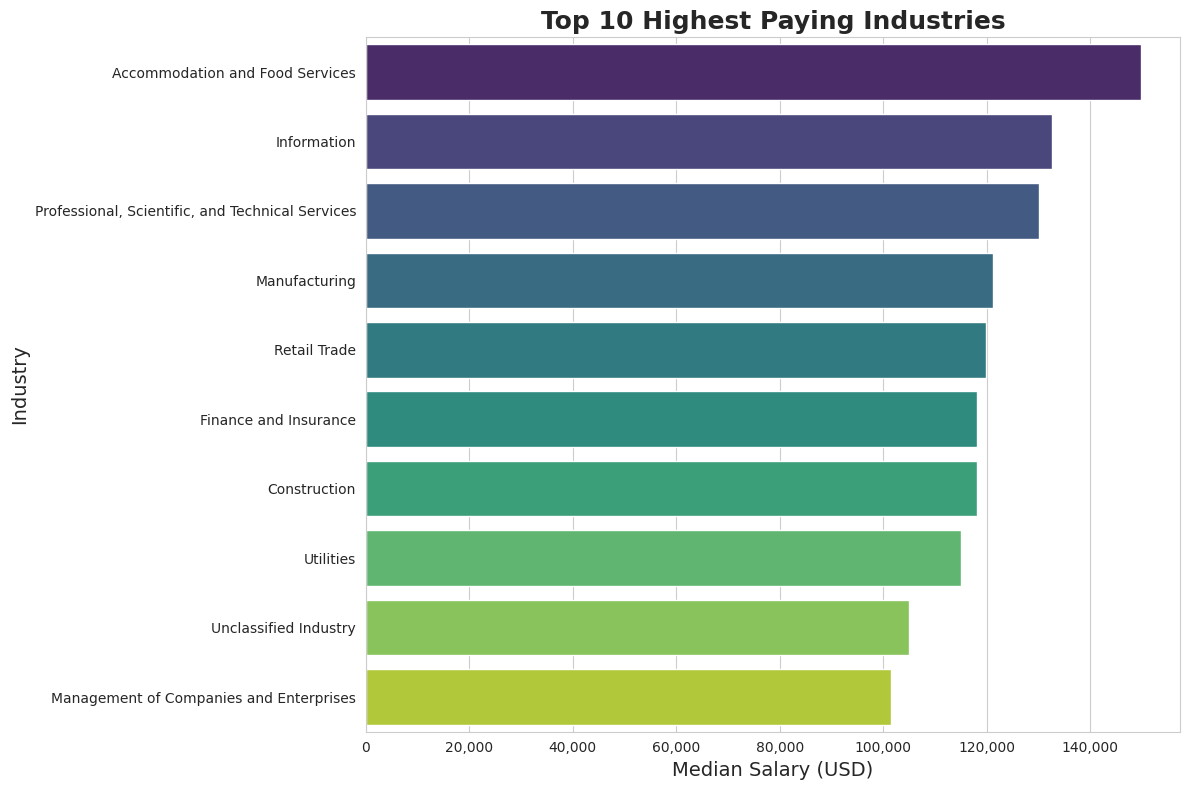

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_style("whitegrid")  

plt.figure(figsize=(12,8))

ax = sns.barplot(
    x=industry_salary.values,
    y=industry_salary.index,
    palette="viridis"
)

# Title & labels
plt.title("Top 10 Highest Paying Industries", fontsize=18, weight="bold")
plt.xlabel("Median Salary (USD)", fontsize=14)
plt.ylabel("Industry", fontsize=14)

# Add comma formatting to the x-axis
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Tight layout for spacing
plt.tight_layout()

plt.show()



The chart above highlights the ten highest-paying industries in the labor market based on median salary levels. Accommodation and Food Services unexpectedly ranks at the top, driven largely by high-salary executive, managerial, and corporate leadership roles within major hospitality and food-service corporations. Industries such as Information and Professional, Scientific, and Technical Services also appear at the top of the salary distribution, reflecting the strong demand for specialized technical skills, data expertise, and management roles within these sectors.

Manufacturing, Retail Trade, Finance and Insurance, and Construction also maintain competitive median salaries, indicating continued economic strength and a need for skilled workers across technical and operational roles. Even industries like Utilities and Unclassified Industry categories show high median pay, often influenced by regulated wages, unionized labor, and specialized technical positions. Overall, the ranking demonstrates that high salaries are not limited to traditional white-collar fields, many essential and operational industries continue to offer substantial earning potential in today’s job market.

## 3. Remote vs. On-Site Salary Comparison
*Here, we compare compensation differences between remote, hybrid, and in-office roles.*

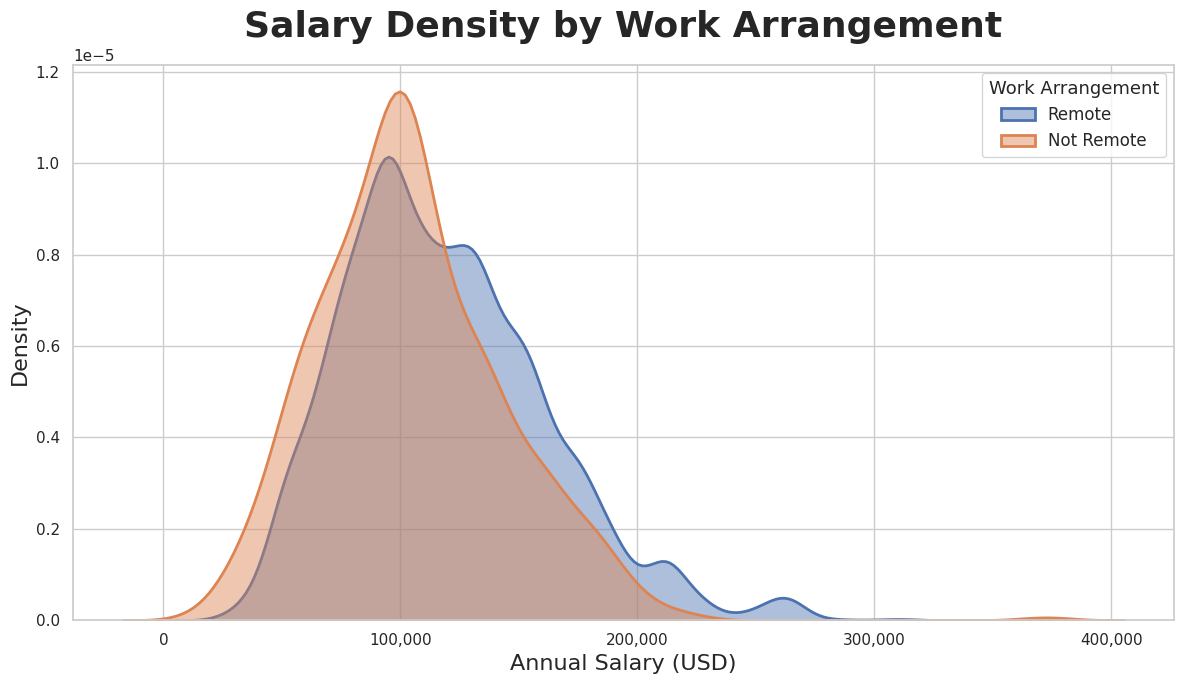

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,7))

# Make a clean copy for remote analysis
df_remote = df.copy()

# Keep only rows where remote type is known
df_remote = df_remote[df_remote["REMOTE_TYPE_NAME"].notna()]

# Ensure SALARY is numeric
df_remote["SALARY"] = pd.to_numeric(df_remote["SALARY"], errors="coerce")
df_remote = df_remote[df_remote["SALARY"].notna()]


sns.kdeplot(
    df_remote[df_remote["REMOTE_TYPE_NAME"] == "Remote"]["SALARY"],
    fill=True, alpha=0.45, linewidth=2,
    label="Remote"
)

sns.kdeplot(
    df_remote[df_remote["REMOTE_TYPE_NAME"] == "Not Remote"]["SALARY"],
    fill=True, alpha=0.45, linewidth=2,
    label="Not Remote"
)


plt.title(
    "Salary Density by Work Arrangement",
    fontsize=26,
    weight="bold",
    loc="center",    
    pad=20           
)

plt.xlabel("Annual Salary (USD)", fontsize=16)
plt.ylabel("Density", fontsize=16)

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.legend(title="Work Arrangement", fontsize=12, title_fontsize=13, loc="upper right")
plt.tight_layout()
plt.show()



The salary density chart highlights clear differences between remote and non-remote work arrangements. Both groups peak around the $90,000–$110,000 range, indicating that this salary band represents the most common earning level across the dataset. However, the remote group exhibits a noticeably wider and longer right tail, with salaries extending well beyond $250,000 and reaching above $350,000. In contrast, non-remote salaries taper off much earlier, with far fewer roles exceeding $200,000.

This distribution suggests that remote positions are more heavily represented in high-paying fields such as technology, data science, cybersecurity, and other specialized knowledge-based roles. The broader spread of remote salaries also indicates greater variability, meaning remote work encompasses both mid-level and highly senior or niche positions. Meanwhile, the tighter clustering of non-remote salaries reflects more uniform pay structures often found in operational, in-person, or location-dependent industries.

Overall, the density comparison demonstrates that while typical salaries are similar between the two groups, remote jobs offer significantly higher earning potential, aligning with current labor market trends favoring flexible, high-skill digital roles.

## 4. State-Level Salary Patterns
*This section highlights geographic variation in median earnings across states.*

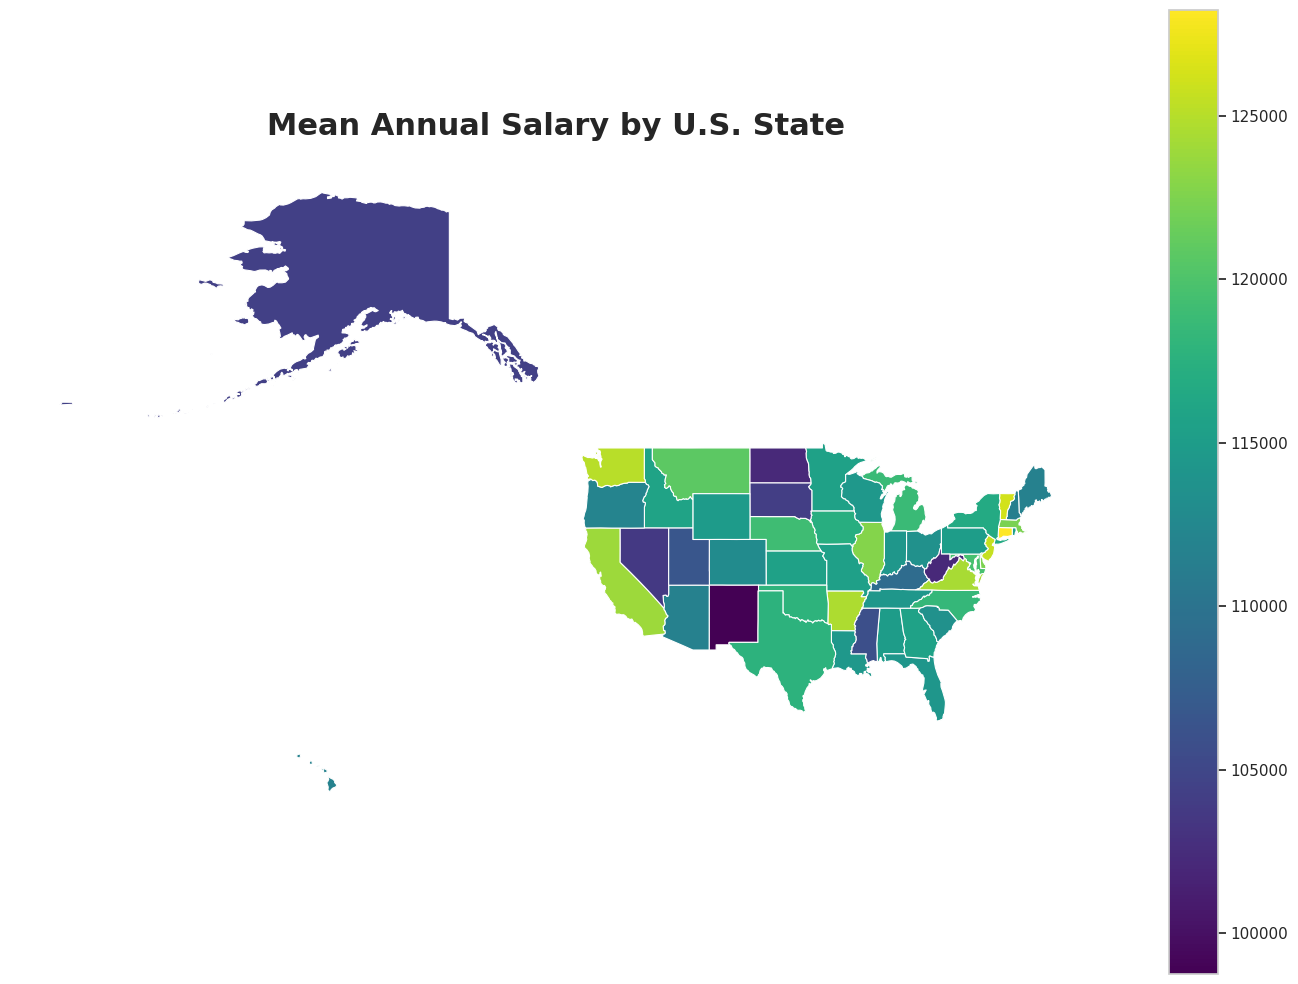

In [13]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO

# ---- LOAD US STATES GEOJSON ----
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
response = requests.get(geojson_url)
states_gdf = gpd.read_file(StringIO(response.text))

# ---- PREPARE LIGHTCAST DATA ----
df_map = df.copy()

df_map = df_map[df_map["STATE_NAME"].notna()]
df_map["SALARY"] = pd.to_numeric(df_map["SALARY"], errors="coerce")
df_map = df_map[df_map["SALARY"].notna()]
df_map["STATE_NAME"] = df_map["STATE_NAME"].str.strip()

# Fix DC naming difference
df_map["STATE_NAME"] = df_map["STATE_NAME"].replace({
    "District of Columbia": "District of Columbia"
})

# Compute state-level mean salary
state_salary = (
    df_map.groupby("STATE_NAME")["SALARY"]
    .mean()
    .reset_index()
)

# ---- MERGE GEO DATA WITH SALARY DATA ----
merged = states_gdf.merge(state_salary, left_on="name", right_on="STATE_NAME", how="left")

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(14, 10))

merged.plot(
    column="SALARY",
    cmap="viridis",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    ax=ax
)

plt.title(
    "Mean Annual Salary by U.S. State",
    fontsize=22,
    weight="bold",
    pad=20
)

plt.axis("off")
plt.tight_layout()
plt.show()


The choropleth map reveals clear geographic patterns in U.S. salary distribution, reflecting both regional economic structures and cost-of-living dynamics. States on the West Coast and in the Northeast consistently exhibit the highest average annual salaries, with several surpassing $120,000. California and Washington, for example, benefit from strong concentrations of technology, biotech, and advanced services industries, which drive salaries upward. Similarly, states such as New York, New Jersey, and Massachusetts reflect the influence of finance, healthcare, and professional services hubs, contributing to some of the highest compensation levels in the country.

In contrast, many Southern and Midwestern states cluster toward the lower end of the salary distribution, with averages frequently between $100,000 and $110,000. These states tend to be characterized by lower costs of living, a greater proportion of traditional industries, and less concentration of high-income professional sectors. Notably, the states with the lowest mean salaries in this dataset fall just under $100,000, while the highest exceed $128,000, producing a spread of nearly $30,000 across the country.

Overall, the national average salary in this dataset is approximately $114,000. Though salary levels vary significantly across regions, this variation aligns closely with broader economic trends, including labor market specialization, urbanization, and local demand for high-skill occupations. The resulting geographic landscape provides valuable context for understanding compensation differences and highlights how location continues to play a substantial role in shaping earnings potential in the United States.